<center> CROP MAPPING WITH SENTINEL-2 IN GOOGLE COLAB <br><br> Case Study: Kellogg Biological Station (LTER) - August 2023 </center>
<center><img src='https://drive.google.com/uc?id=1GadLbGxmmZJlbcI9_IIIG2rNRbxVy3ab' width="700" height= '700'/></center>
<center>Kellogg Biological Station (LTER), Kalamazoo - Michigan </center>
<br>
<br>
<p style='text-align: justify;'> Cropland monitoring is essential for obtaining reliable information that drives critical decision-making in addressing issues such as population growth and climate change. The monitoring frequency and coverage of satellite-based observations makes it one of the most efficient ways to ensure increase in food production and environmental sustainability.

This exercise focuses on classifying different crops types at the Kellogg Biological Station (LTER) in Michigan, using optical satellite data from ESA's Sentinel-2 Missions. The analysis will be implemented using python code in a Google Colab environment.  </p>


<p style='text-align: justify;'> The exercise <strong>DOES NOT</strong> require any Python programming skills and can be followed by any participant. You will not be asked to write any code but to follow the methodology and understand the processing steps. If you are new to Python and/or Google colab, here are some resources that can help you:</p>


- [Python Tutorial](https://docs.python.org/3/tutorial/)
- [Google Cobab, by Google](https://research.google.com/colaboratory/)
- [Google Colab](https://neptune.ai/blog/google-colab-dealing-with-files)



The exercise is divided into the following sections:
1. Install and load python packages
2. Load and visualize input data
3. Create custom functions
4. Prepare/extract training data
5. Build Random Forest model
6. Classify entire image and export results

Tip: To run a cell, click in it and press SHIFT + ENTER


## 1. Install and load packages

In [1]:
# installs packages
#!pip install rasterio
#!pip install earthpy

# loads packages                                                                             # DESCRIPTION
import numpy as np                                                                           # scientific computing
import matplotlib as mtp                                                                     # visualization
import matplotlib.pyplot as plt                                                              # visualization
import pandas as pd                                                                          # data analysis and manipulation
import geopandas as gpd                                                                      # data analysis and manipulation for geospatial (vector) data
import rasterio                                                                              # reads, performs spatial operation, plots, and writes raster data
from rasterio.plot import show, reshape_as_raster, reshape_as_image, plotting_extent         # reads, performs spatial operation, plots, and writes raster data
import earthpy.plot as ep                                                                    # plots and performs spatial operation on both raster and vector data
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold       # data analysis and machine learning
from sklearn.ensemble import RandomForestClassifier                                          # data analysis and machine learning
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # data analysis and machine learning
import os                                                                                    # operating system

In [3]:
# connects notebook to the base data directory
#os.chdir('/content/drive/My Drive/Ohioview/')

# loads Sentinel2 stacked bands into a dataset object
#image= rasterio.open('Image_data/base_data.tif')
#image= rasterio.open('Image_data/ohlio_august1_clip.tif')
image= rasterio.open('Image_data/ohlio_august2.tif')
#image= rasterio.open('ohlio_september.tif')
#image= rasterio.open('ohlio_july2.tif')
#image= rasterio.open('july_composite.tif')

# reads the polygons
plots= gpd.read_file('Shapefiles/42_plots/plots.shp')

# metadata
profile= image.profile


class_names = ['corn', 'poplar', 'switchgrass', 'T7']  # Four classes represented in our training data

##2. Import and visualize input data
Input data includes:
1. Stacked Sentinel-2 bands in GeoTIFF (blue, green, red, red band, NIR).
2. Polygon shapefile that represents the crop fields.
3. Point shapefile for extracting training features.

### 2.1 Data input

### 2.2 Image visualization

(5, 100, 100)


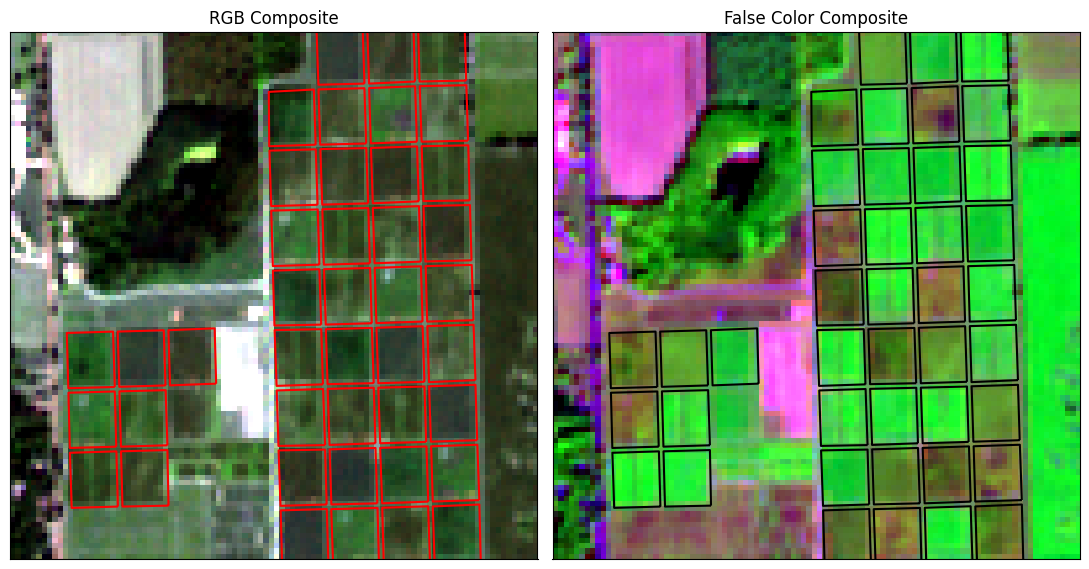

In [4]:
# read all bands of the dataset into 3-dimensional array stack - (band, row, column)
stack = image.read()
#print(stack)
print(stack.shape)

# extent of raster
stack_ext= plotting_extent(image)

# visualizes RGB and false color composite bands
fig, axs= plt.subplots(nrows= 1, ncols= 2, figsize= (11, 9))
axs[0]= ep.plot_rgb(arr= stack, rgb= (2, 1, 0), stretch= True, ax= axs[0], title= 'RGB Composite', extent= stack_ext)
axs[0]= plots.boundary.plot(edgecolor= 'red', ax= axs[0]) # overlays the plots of interest on raster as red polygons

axs[0]= ep.plot_rgb(arr= stack, rgb= (4, 3, 2), stretch= True, ax= axs[1], title= 'False Color Composite', extent= stack_ext) # false color composite
axs[0]= plots.boundary.plot(edgecolor= 'black', ax= axs[1]) # overlays the plots of interest on raster as black polygons
plt.tight_layout()

## 3. Custom functions for extracting features

In [5]:
# creates a function that derives NDVI
def NDVI (NIR, RED):
  return (NIR-RED)/(NIR+RED)

# creates a function that derives NDRE
def NDRE (NIR, RE):
  return (NIR-RE)/(NIR+RE)


NDVI_band= NDVI(NIR= stack[4], RED= stack[2]) # calculates NDVI
#print(NDVI_band)
#show(NDVI_band, cmap="Greys_r")
NDRE_band= NDRE(NIR= stack[4], RE= stack[3]) # calculated NDRE
#print(NDRE_band)


# stacks the extracted features to the base data
single_bands= [x for x in stack] #extracts each band array and puts it into a list
bands_VIs= np.array([*single_bands, NDVI_band, NDRE_band])

### 3.2 Export raster data


In [6]:
# we will use the profile of our base image data to export our new multiband raster,
# but we need to update the 'count' and 'dtype' parameters since our new raster has 7 bands and the VIs are in float
profile.update(count=7, dtype= 'float64', compress='lzw')
with rasterio.open('S2bands_VIs.tif', mode= 'w', **profile) as new_data:
  new_data.write(bands_VIs)

## 4. Extract training features

In [7]:
# opens our new 7 multiband raster
feat_7= rasterio.open('S2bands_VIs.tif')
names= ['Blue', 'Green', 'Red', 'Red_Edge', 'NIR', 'NDVI', 'NDRE'] # band names for our new raster

# reads points from shapefile
train_pts= gpd.read_file('Shapefiles/184/training_vector_points.shp')
train_pts.rename(columns= {'Treatment':'crop_ID'}, inplace= True) # renames the column with the training labels
coords = [(x,y) for x, y in zip(train_pts.POINT_X, train_pts.POINT_Y)]  # creates a list of point coordinates pairs (X, Y)


# Sample each band of raster dataset at each point in the coordinate list
train_pts['Raster Value'] = [x for x in feat_7.sample(coords)]   # for each point coordinate, all band values are in a list in the Raster Value column


# Unpack the Raster Value column to separate column for each band
train_pts[names] = pd.DataFrame(train_pts['Raster Value'].tolist())
train_pts = train_pts.drop(['Raster Value', 'POINT_X', 'POINT_Y', 'geometry'], axis=1) # Removes unwanted columns from the final training data table


train_pts['crop_ID'] = train_pts['crop_ID'].replace([1,5,6,7],[1,2,3,4]) # changes the labels of the crop types

print(f"{train_pts.head()}\n") # shows the first 5 rows of the dataframe
print(f"Number of training points: {len(train_pts)}\n")
print(f"The unique values for the crop types: {train_pts['crop_ID'].unique()}\n")
print(f"The number of training points for each crop type:\n {train_pts['crop_ID'].value_counts()}")

   crop_ID    Blue   Green     Red  Red_Edge     NIR      NDVI      NDRE
0        1  0.0274  0.0472  0.0294    0.4483  0.0622  0.358079 -0.756317
1        1  0.0253  0.0455  0.0271    0.4403  0.0590  0.370499 -0.763669
2        1  0.0290  0.0504  0.0297    0.4616  0.0685  0.395112 -0.741558
3        1  0.0278  0.0488  0.0284    0.4632  0.0812  0.481752 -0.701690
4        1  0.0302  0.0534  0.0282    0.4645  0.0717  0.435435 -0.732562

Number of training points: 184

The unique values for the crop types: [1 4 3 2]

The number of training points for each crop type:
 crop_ID
1    70
4    38
3    38
2    38
Name: count, dtype: int64


## 5. Build Random Forest Model
Random Forest is an ensemble algorithm that combines the output of different models (decision trees) to make an estimation. Decision trees are predictive models that sequentially split a dataset into homogenous groups by using a set of binary rules to calculate a target value. Given a training set with n number of samples and m number of variables, a random subset of samples n is selected with replacement (bagging approach) and used to construct a tree. At each node of the tree, a random selection of variables m is used and, out of these variables, only the one providing the best split is used to create two sub-nodes.

Random Forest can be used for machine learning tasks like classification and regression. In this classification task, each pixel in our multiband raster will be classified by all the trees of the Random Forest algorithm, producing as many classifications as the number of trees. Each tree votes for a class membership and then, the class with the maximum number of votes is selected as the final class.

### 5.1 Train the Random Forest model

In [8]:
# set features and labels
features= train_pts.iloc[:, 1:] # features
labels= train_pts['crop_ID'] # labels

# splits data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(features,labels, random_state=0,test_size=0.30, shuffle=True, stratify= labels)
y_test.value_counts()

crop_ID
1    21
3    12
2    12
4    11
Name: count, dtype: int64

In [9]:
rf = RandomForestClassifier(random_state= 0, oob_score= True)   # Initializes model with the default parameters
model= rf.fit(x_train, y_train)   # Fit the model to the training dataset
print(f'OOB score for our model is {model.oob_score_ * 100}')

OOB score for our model is 96.09375


### 5.2 Model Validation

In [10]:
# cross validation on training set
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 42)
scores = cross_val_score(rf, x_train, y_train, cv=skf)
print(scores)
np.mean(scores)

[0.92307692 0.96153846 1.         1.         0.96      ]


0.9689230769230768

              precision    recall  f1-score   support

        corn       0.95      1.00      0.98        21
      poplar       1.00      0.92      0.96        12
 switchgrass       0.86      1.00      0.92        12
          T7       1.00      0.82      0.90        11

    accuracy                           0.95        56
   macro avg       0.95      0.93      0.94        56
weighted avg       0.95      0.95      0.95        56



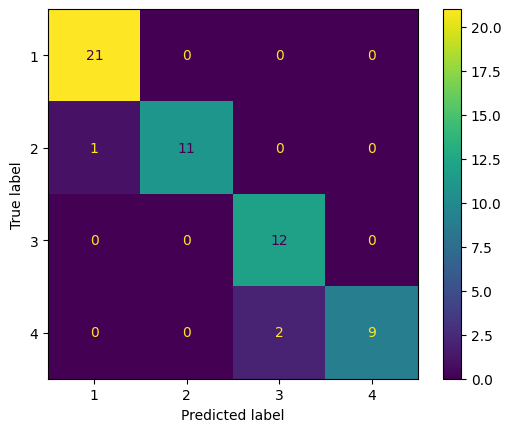

In [11]:
# validation on testing set
y_pred= model.predict(x_test)
#rf.score(x_test, y_test) # overall accuracy
print(classification_report(y_test, y_pred, target_names=class_names))  # Print the classification report

# Plots a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= rf.classes_)
disp.plot()

## 6. Classify image with the trained RF model

In [12]:
img_profile= feat_7.profile
img_val= list(img_profile.values())
rows= img_val[4] # no of rows
cols= img_val[3] # no of columns
band_count= img_val[5] # no of bands


img_array= feat_7.read()
img_array_1= reshape_as_image(img_array) # reshapes as row , column, and band
img_array_2= np.reshape(img_array_1, [rows*cols, band_count]) # 2D array (row*columns, bands)

In [13]:
# creates a dataframe from the array, for visulization
img_df= pd.DataFrame(img_array_2, dtype= 'float32')
img_df.columns= names
img_df.head()

,Blue,Green,Red,Red_Edge,NIR,NDVI,NDRE
0,0.0630,0.0724,0.0421,0.3332,0.1208,0.483118,-0.467841
1,0.0615,0.0734,0.0424,0.3453,0.1217,0.483242,-0.478801
2,0.0577,0.0715,0.0396,0.3419,0.1217,0.508989,-0.474978
3,0.0521,0.0642,0.0378,0.3339,0.0990,0.447368,-0.542620
4,0.0340,0.0549,0.0281,0.2895,0.0990,0.557828,-0.490348


In [14]:
img_pred= model.predict(img_array_2) # classify the entire image with our model

/home/duplex/anaconda3/envs/gee/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
print(np.unique(img_pred)) # unique values in our classification results

[1 2 3 4]


### 6.1 Visualize results

In [16]:
img_pred_1= img_pred.reshape((rows, cols)) # reshape back to a 2D array of rows and columns for visualization

In [17]:
# Create matplotlib colormap from a list of colors and call it Classification
colors = ['blue', 'green', 'red', 'orange']
cmap = plt.matplotlib.colors.ListedColormap(colors, 'our_colors', 4)

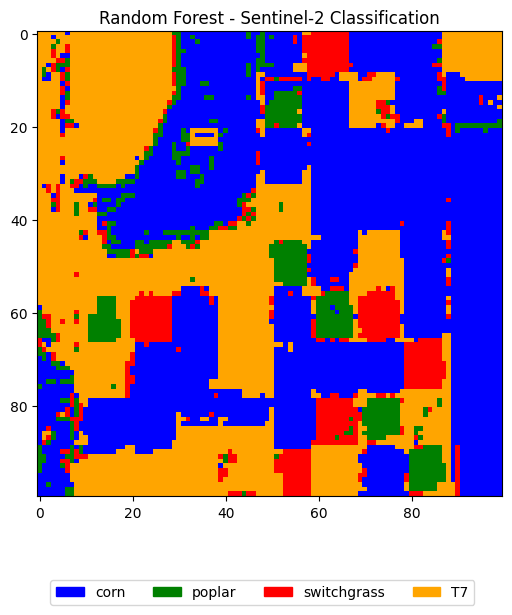

In [18]:
# plot classification results
fig, ax= plt.subplots(figsize= (6, 9))
ax.set_title('Random Forest - Sentinel-2 Classification')
ax.imshow(img_pred_1, cmap= cmap)

# Create a legend with class names and colors
patches = [mtp.patches.Patch(color=cmap(i), label="{:s}".format(class_names[i]) ) for i in range(len(class_names))]
fig.legend(handles=patches, loc='center', bbox_to_anchor=(0.5, 0.13), ncol=4 )

In [19]:
image.width

100

### 6.2 Export results

In [20]:
img_pred_1= img_pred_1.reshape((1, image.height, image.width)) # reshape back to a 3 dimensional array
#img_pred_1= img_pred_1.reshape((1, 110, 92)) # reshape back to a 3 dimensional array

# Save the classification results as a GeoTIFF
with rasterio.Env():
    # Write an array as a raster band to a new 8-bit file.
    # For the new file's profile, we will use the profile of the source
    # change the band count to 1, set the dtype to uint8, and specify LZW compression.
    profile.update(dtype=rasterio.uint8, count=1, compress='lzw')
    with rasterio.open('RF_classification.tif', 'w', **profile) as result:
        result.write(img_pred_1.astype(rasterio.uint8))